In [2]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Aplique nas imagens abaixo o algortimo Watershed para realizar a contagem de células. Faça tanto para  a imagem original e para a imagem gradiente

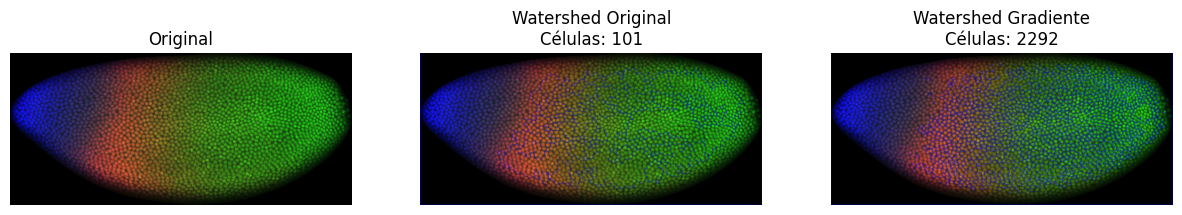

In [9]:
# ==========================
# WATERSHED - IMAGE 1
# ==========================

img = cv2.imread("image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---------- Watershed na imagem original ----------

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(
    dist,
    0.35*dist.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

num_labels, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown==255] = 0

img_ws = img.copy()
markers = cv2.watershed(img_ws, markers)
img_ws[markers==-1] = [255,0,0]

num_cells = len(np.unique(markers)) - 2


# ---------- Watershed no gradiente ----------

gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)

_, thresh2 = cv2.threshold(
    gradient,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

opening = cv2.morphologyEx(thresh2, cv2.MORPH_OPEN, kernel)

sure_bg = cv2.dilate(opening,kernel,iterations=3)

dist = cv2.distanceTransform(opening, cv2.DIST_L2,5)

_, sure_fg = cv2.threshold(
    dist,
    0.35*dist.max(),
    255,
    0
)

sure_fg=np.uint8(sure_fg)

unknown=cv2.subtract(sure_bg,sure_fg)

num_labels,markers=cv2.connectedComponents(sure_fg)

markers=markers+1

markers[unknown==255]=0

img_grad=img.copy()

markers=cv2.watershed(img_grad,markers)

img_grad[markers==-1]=[255,0,0]

num_cells_grad=len(np.unique(markers))-2

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.cvtColor(img_ws,cv2.COLOR_BGR2RGB))
plt.title(f"Watershed Original\nCélulas: {num_cells}")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(img_grad,cv2.COLOR_BGR2RGB))
plt.title(f"Watershed Gradiente\nCélulas: {num_cells_grad}")
plt.axis("off")

plt.show()

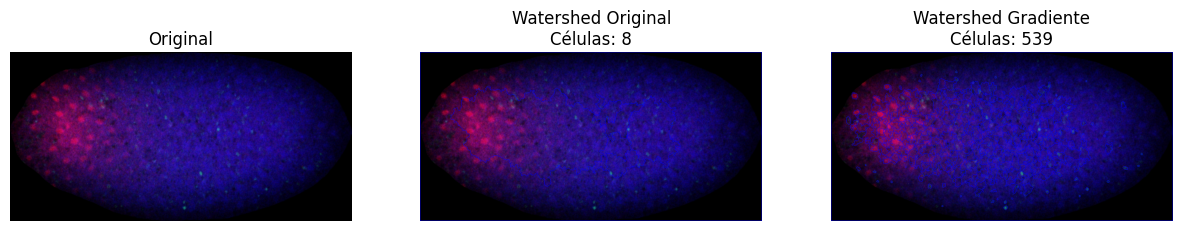

In [ ]:

img = cv2.imread("image2.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,0,255,
                           cv2.THRESH_BINARY+cv2.THRESH_OTSU)

kernel=np.ones((3,3),np.uint8)

opening=cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations=2)

sure_bg=cv2.dilate(opening,kernel,iterations=3)

dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)

_,sure_fg=cv2.threshold(dist,0.35*dist.max(),255,0)

sure_fg=np.uint8(sure_fg)

unknown=cv2.subtract(sure_bg,sure_fg)

_,markers=cv2.connectedComponents(sure_fg)

markers=markers+1

markers[unknown==255]=0

img_ws=img.copy()

markers=cv2.watershed(img_ws,markers)

img_ws[markers==-1]=[255,0,0]

num_cells=len(np.unique(markers))-2


gradient=cv2.morphologyEx(gray,cv2.MORPH_GRADIENT,kernel)

_,thresh2=cv2.threshold(gradient,0,255,
                        cv2.THRESH_BINARY+cv2.THRESH_OTSU)

opening=cv2.morphologyEx(thresh2,cv2.MORPH_OPEN,kernel)

sure_bg=cv2.dilate(opening,kernel,iterations=3)

dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)

_,sure_fg=cv2.threshold(dist,0.35*dist.max(),255,0)

sure_fg=np.uint8(sure_fg)

unknown=cv2.subtract(sure_bg,sure_fg)

_,markers=cv2.connectedComponents(sure_fg)

markers=markers+1

markers[unknown==255]=0

img_grad=img.copy()

markers=cv2.watershed(img_grad,markers)

img_grad[markers==-1]=[255,0,0]

num_cells_grad=len(np.unique(markers))-2

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.cvtColor(img_ws,cv2.COLOR_BGR2RGB))
plt.title(f"Watershed Original\nCélulas: {num_cells}")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(img_grad,cv2.COLOR_BGR2RGB))
plt.title(f"Watershed Gradiente\nCélulas: {num_cells_grad}")
plt.axis("off")

plt.show()

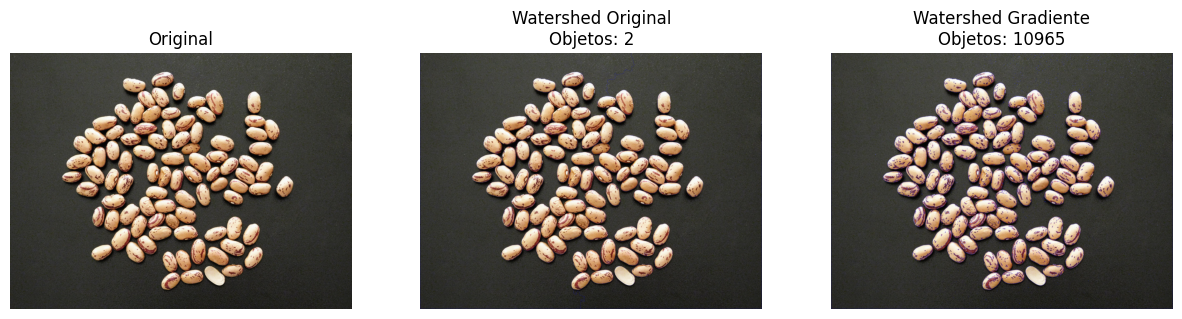

In [13]:

img = cv2.imread("feijao.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,0,255,
                           cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

kernel=np.ones((3,3),np.uint8)

opening=cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations=2)

sure_bg=cv2.dilate(opening,kernel,iterations=3)

dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)

_,sure_fg=cv2.threshold(dist,0.30*dist.max(),255,0)

sure_fg=np.uint8(sure_fg)

unknown=cv2.subtract(sure_bg,sure_fg)

_,markers=cv2.connectedComponents(sure_fg)

markers=markers+1

markers[unknown==255]=0

img_ws=img.copy()

markers=cv2.watershed(img_ws,markers)

img_ws[markers==-1]=[255,0,0]

num_obj=len(np.unique(markers))-2


gradient=cv2.morphologyEx(gray,cv2.MORPH_GRADIENT,kernel)

_,thresh2=cv2.threshold(gradient,0,255,
                        cv2.THRESH_BINARY+cv2.THRESH_OTSU)

opening=cv2.morphologyEx(thresh2,cv2.MORPH_OPEN,kernel)

sure_bg=cv2.dilate(opening,kernel,iterations=3)

dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)

_,sure_fg=cv2.threshold(dist,0.30*dist.max(),255,0)

sure_fg=np.uint8(sure_fg)

unknown=cv2.subtract(sure_bg,sure_fg)

_,markers=cv2.connectedComponents(sure_fg)

markers=markers+1

markers[unknown==255]=0

img_grad=img.copy()

markers=cv2.watershed(img_grad,markers)

img_grad[markers==-1]=[255,0,0]

num_obj_grad=len(np.unique(markers))-2

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.cvtColor(img_ws,cv2.COLOR_BGR2RGB))
plt.title(f"Watershed Original\nObjetos: {num_obj}")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(img_grad,cv2.COLOR_BGR2RGB))
plt.title(f"Watershed Gradiente\nObjetos: {num_obj_grad}")
plt.axis("off")

plt.show()